In [56]:
!pip install kagglehub pandas scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rng = 42

# Rain in Australia

## Motivation and Question

## Target Variable and Class Labels

## Data Source, Observations, and Main Features

### Import Dataset

In [4]:
import kagglehub
from pathlib import Path

# Download latest version
handle = "jsphyg/weather-dataset-rattle-package"
path = "weatherAUS.csv"
if not Path(path).exists():
    print("Downloading from Kaggle")
    path = kagglehub.dataset_download(
        "jsphyg/weather-dataset-rattle-package",
        "weatherAUS.csv",
        output_dir="."
    )

print("Path to dataset files:", path)

Path to dataset files: weatherAUS.csv


/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd

df = pd.read_csv(path)

## Cleaning and Preprocessing

* Handling null values should happend before enrichment.
    * Except some enrichment should happend before getting rid of null values. For example, consecutive rain days
* Enrichment should happen before EDA
* EDA should happen before preprocessing
* Some amount of EDA should handle any imputed (estimated and added in) null values, if we're using any
    * E.g. Box plot with and without imputed values

* Handle categorical values ([ordinal][sklearn.preprocessing.OrdinalEncoder], [one-hot][sklearn.preprocessing.OneHotEncoder], [target][sklearn.preprocessing.TargetEncoder])
* [Standardize scalers][sklearn.preprocessing.StandardScaler]?
* Handle null values
    * Delete: simply drop any rows/columns with missing values, especially if they are few and missingness is random
    * Impute: replace with estimated values
        * with mean, median, or mode
        * using forward/backward fill - duplicating in the previous/next seen value...
    * Interpolate from nearby values...

[sklearn.preprocessing.OrdinalEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder
[sklearn.preprocessing.OneHotEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder
[sklearn.preprocessing.TargetEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.TargetEncoder.html#sklearn.preprocessing.TargetEncoder
[sklearn.preprocessing.StandardScaler]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.StandardScaler.html

According to the [Australian Government's Bureau of Meterology](https://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml), "From time to time, observations will not be available, for a variety of reasons. Sometimes when the daily maximum and minimum temperatures, rainfall or evaporation are missing, the next value given has been accumulated over several days rather than the normal one day. It is very difficult for an automatic system to detect this reliably, so caution is advised."

In [6]:
print(f"Number of columns with a significant amount of missing data: {((df.isnull().sum() / df.shape[0]) > 0.05).sum()} / {df.shape[1]} = {((df.isnull().sum() / df.shape[0]) > 0.05).sum() / df.shape[1]}")
print(f"Number of rows with at least one missing feature: {(df.isnull().sum(axis=1) > 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) > 0).sum() / df.shape[0]}")
print(f"Number of rows with more than one missing feature: {(df.isnull().sum(axis=1) > 2).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) > 2).sum() / df.shape[0]}")

Number of columns with a significant amount of missing data: 9 / 23 = 0.391304347826087
Number of rows with at least one missing feature: 89040 / 145460 = 0.6121270452358036
Number of rows with more than one missing feature: 59785 / 145460 = 0.41100646225766535


### Enrich Dataset
- TempRange — MaxTemp minus MinTemp
- MonsoonSeason — location-aware wet/monsoon flag (Yes/No)
- WindSpeedDiff — WindSpeed3pm minus WindSpeed9am (signed)
- HumidityDiff — Humidity3pm minus Humidity9am (signed)
- TempDiff9am3pm — Temp3pm minus Temp9am (signed)
- PressureDiff — Pressure3pm minus Pressure9am (signed)
- DewPoint9am — dew point from 9am temp and humidity
- Season — Southern Hemisphere season from date
- DaysSinceRain — days since last rain per location
- ConsecutiveRainDays — consecutive rainy days before current day
- LaNina — monthly La Niña flag from NOAA NINO3.4 anomaly

In [7]:
from enrich_weather import enrich
df = enrich(df)

In [8]:
print("Number of columns with a significant amount of missing data", ((df.isnull().sum() / df.shape[0]) > 0.05).sum())
print(f"Number of rows with no missing features: {(df.isnull().sum(axis=1) == 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) == 0).sum() / df.shape[0]}")

Number of columns with a significant amount of missing data 10
Number of rows with no missing features: 56046 / 145460 = 0.38530180118245566


## Exploratory Data Analysis
e.g. Description: columns, data-types, null values, counts, mean, standard deviation, box plot: min, 25%, 50%, 75% max; Distribution: target, target vs. key features, correlation matrix; target class balance

## Train-Test Split

In [9]:
# TODO: This is not an acceptable handling of null values. But it's good enough for getting started on the modelling
df = df.dropna()
print(f"Number of rows with no missing features: {(df.isnull().sum(axis=1) == 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) == 0).sum() / df.shape[0]}")

Number of rows with no missing features: 56046 / 56046 = 1.0


### Preprocessing

[This wind modelling project](https://www.codespeedy.com/wind-direction-and-speed-prediction-using-machine-learning-in-python/) just uses degrees for the wind direction and get... passable results. I also can't think of a way to properly encode that mod activity of compass directions. One could just do it like this and another way (probably One-Hot) and see if you get a difference.

In [10]:
DIRECTIONS = ['N', 'NNE', 'NE', 'ENE',
              'E', 'ESE', 'SE', 'SSE', 
              'S', 'SSW', 'SW', 'WSW',
              'W', 'WNW', 'NW', 'NNW']
DEGREES = np.arange(0, 360, 360/len(DIRECTIONS))
DIRECTIONS_DEGREES = dict(zip(DIRECTIONS, DEGREES))
def direc_to_deg(direc: pd.DataFrame) -> float:
    return direc.map(str.upper).map(DIRECTIONS_DEGREES.get)

# Extra 1 and 0 entries for redundancy on multiple runnings
YES_NO_BINARY = { 'Yes': 1, 'No': 0,
                  1: 1,     0: 0 }
def yes_no_binary(b: pd.DataFrame) -> float:
    return b.map(YES_NO_BINARY.get)

In [11]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler

preprocessing = make_column_transformer(
    (FunctionTransformer(direc_to_deg, feature_names_out="one-to-one"), ["WindGustDir", "WindDir9am", "WindDir3pm"]),
    (OneHotEncoder(), ["Location", "Season"]),
    (FunctionTransformer(yes_no_binary, feature_names_out="one-to-one"), ["RainToday", "MonsoonSeason", "LaNina"]),
    (StandardScaler(), ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm", "TempRange", "WindSpeedDiff", "HumidityDiff", "TempDiff9am3pm", "PressureDiff", "DewPoint9am", "DaysSinceRain", "ConsecutiveRainDays"])
)

In [12]:
# Things get funky when the traget needs preprocessing. Easy solution is to just pre-transform the target
df['RainTomorrow'] = FunctionTransformer(yes_no_binary, feature_names_out="one-to-one").fit_transform(df['RainTomorrow'])

### Target-Feature Split, Train-Test Split  

In [13]:
target = 'RainTomorrow'

In [14]:
y = df[target]
X = df.drop(target, axis=1)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

## Modelling

### Simple Model

The only "classifcation model" simplier than logistic regression or a decision tree would be simple descriptions of the model: mode and proportion. Simply use either (i) always guess mode or (ii) randomly guess weighted by proportion.

In [16]:
y_mode = y_train.mode().iloc[0]
y_prop = y_train.mean()

#### Evaluation

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Mode:", y_mode)
pred = np.repeat(y_mode, len(y_train))
print()
print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
print()
print("Classification Report:\n", classification_report(y_train, pred, zero_division=0))
print()
print("Accuracy:", accuracy_score(y_train, pred))

Mode: 0

Confusion Matrix:
 [[32731     0]
 [ 9303     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88     32731
           1       0.00      0.00      0.00      9303

    accuracy                           0.78     42034
   macro avg       0.39      0.50      0.44     42034
weighted avg       0.61      0.78      0.68     42034


Accuracy: 0.7786791644858924


In [18]:
print("Proportion Correct:", y_prop)
pred = np.random.default_rng(rng).choice([1, 0], p=[y_prop, 1-y_prop], size=len(y_train))
print()
print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
print()
print("Classification Report:\n", classification_report(y_train, pred, zero_division=0))
print()
print("Accuracy:", accuracy_score(y_train, pred))


Proportion Correct: 0.22132083551410764

Confusion Matrix:
 [[25549  7182]
 [ 7224  2079]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78     32731
           1       0.22      0.22      0.22      9303

    accuracy                           0.66     42034
   macro avg       0.50      0.50      0.50     42034
weighted avg       0.66      0.66      0.66     42034


Accuracy: 0.6572774420707047


### Interpretable Model
Logistic regression or decision tree

#### Logistic Regression Model

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

lr = make_pipeline(clone(preprocessing), LogisticRegression(random_state=rng, max_iter=10000))
lr.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('functiontransformer-1', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Description

In [20]:
lr_model = lr['logisticregression']
lr_coef = lr_model.coef_[0]
fitted_features = lr['columntransformer'].get_feature_names_out()

In [21]:
fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))

In [22]:
lr_coef = np.append(lr_coef, lr_model.intercept_)
fitted_features.append('Intercept')

In [113]:
def feature_coefs(ax, coefs: list[float], feature_labels: list[str], set_ylabel=False):
    ax.plot(range(len(coefs)), coefs)
    ax.plot(range(len(coefs)), [0]*len(coefs), '--')
    ax.set_xticks(range(len(coefs)), feature_labels, rotation=60, horizontalalignment='right')
    if set_ylabel:
        ax.set_ylabel('Coefficients')
    ax.xaxis.grid()

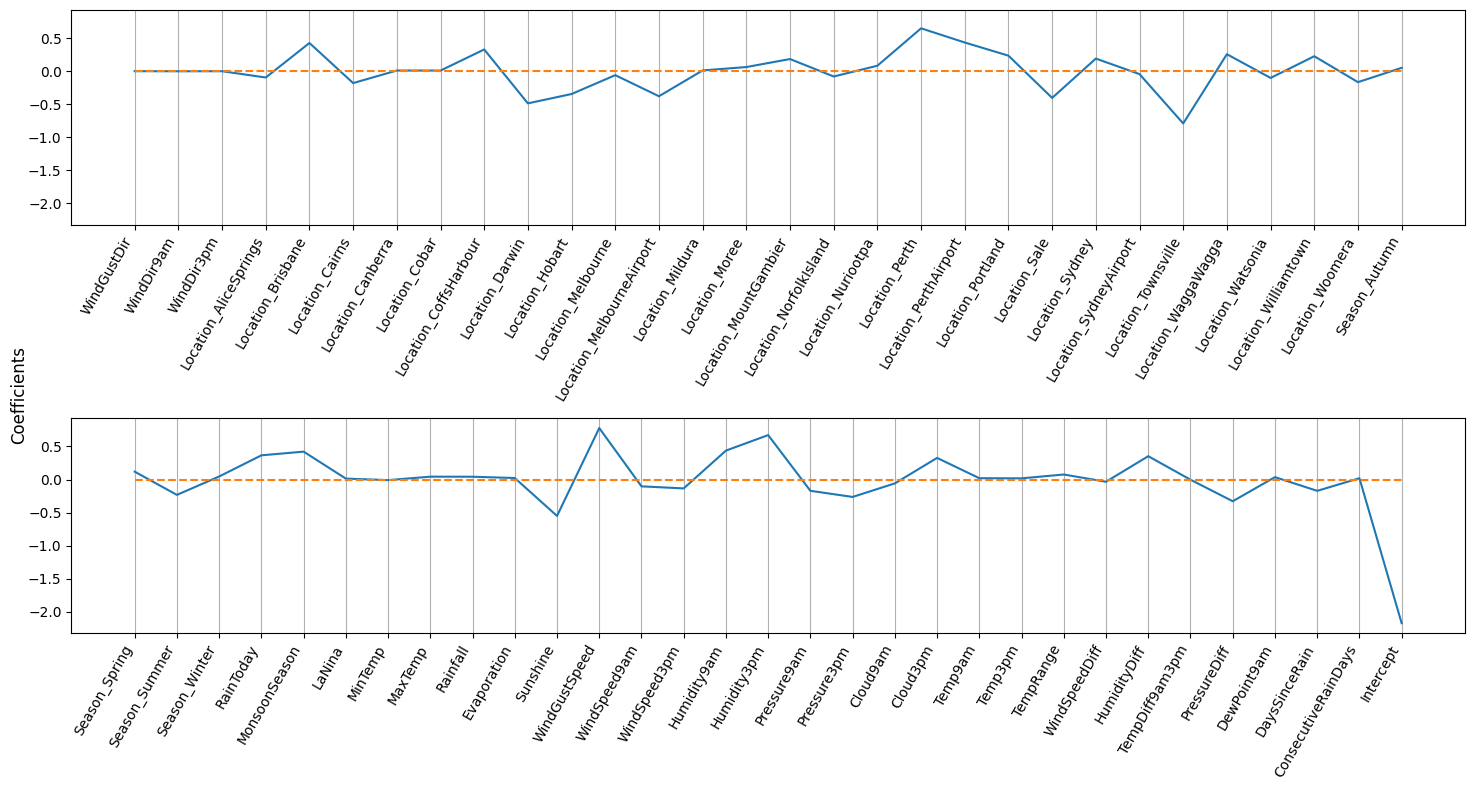

In [114]:
f, axs = plt.subplots(nrows=2, figsize=(15,8))

n_feat = len(fitted_features)
half = n_feat // 2

feature_coefs(axs[0], lr_coef[:half], fitted_features[:half])
feature_coefs(axs[1], lr_coef[half:], fitted_features[half:])
axs[0].sharey(axs[1])
f.supylabel('Coefficients')
f.tight_layout()
plt.show();

#### Optimizing Parameters

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

cs = np.logspace(-4, 4, 100)
lrcv = make_pipeline(
    clone(preprocessing),
    LogisticRegression(max_iter=10000, random_state=rng, warm_start=True)
)

In [27]:
from sklearn.model_selection import cross_val_score
from datetime import datetime

coefs_ = []
scores_ = []
for c in cs:
    print("Running:", c)
    stime = datetime.now()
    lrcv.set_params(logisticregression__C=c)
    lrcv.fit(X_train, y_train)
    coefs_.append(lrcv['logisticregression'].coef_.ravel().copy())
    coefs_[-1] = np.append(coefs_[-1], lrcv['logisticregression'].intercept_)
    scores_.append(cross_val_score(lrcv, X_train, y_train, cv=5))
    print("Took:", datetime.now() - stime)
    print()

coefs_ = np.array(coefs_)
scores_ = np.array(scores_)

Running: 0.0001
Took: 0:00:04.020021

Running: 0.00012045035402587823
Took: 0:00:03.936617

Running: 0.000145082877849594
Took: 0:00:04.146079

Running: 0.0001747528400007683
Took: 0:00:04.354815

Running: 0.00021049041445120198
Took: 0:00:04.587642

Running: 0.00025353644939701115
Took: 0:00:05.207697

Running: 0.0003053855508833416
Took: 0:00:05.468397

Running: 0.0003678379771828634
Took: 0:00:05.506863

Running: 0.0004430621457583882
Took: 0:00:06.333198

Running: 0.0005336699231206312
Took: 0:00:06.429881

Running: 0.0006428073117284319
Took: 0:00:06.473479

Running: 0.000774263682681127
Took: 0:00:07.307289

Running: 0.0009326033468832199
Took: 0:00:07.633466

Running: 0.0011233240329780276
Took: 0:00:07.047698

Running: 0.0013530477745798076
Took: 0:00:08.899217

Running: 0.0016297508346206436
Took: 0:00:08.833585

Running: 0.0019630406500402726
Took: 0:00:09.617433

Running: 0.002364489412645407


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Colorblind-friendly palette (IBM Color Blind Safe palette)
colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100"]

plt.figure(figsize=(10, 6))
for i in range(coefs_.shape[1]):
    plt.semilogx(cs, coefs_[:, i], marker="o", label=feature_names[i])

ymin, ymax = plt.ylim()
plt.xlabel("C")
plt.ylabel("Coefficients")
plt.title("Logistic Regression Path")
plt.legend()
plt.axis("tight")
plt.show()

In [71]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
cs = np.logspace(-6, 1, 1000)
lrcv = make_pipeline(clone(preprocessing), LogisticRegressionCV(Cs=cs, max_iter=10000, random_state=rng))
lrcv.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('functiontransformer-1', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
lrcv_model = lrcv['logisticregressioncv']
coefs_ = lrcv_model.coefs_paths_[1]

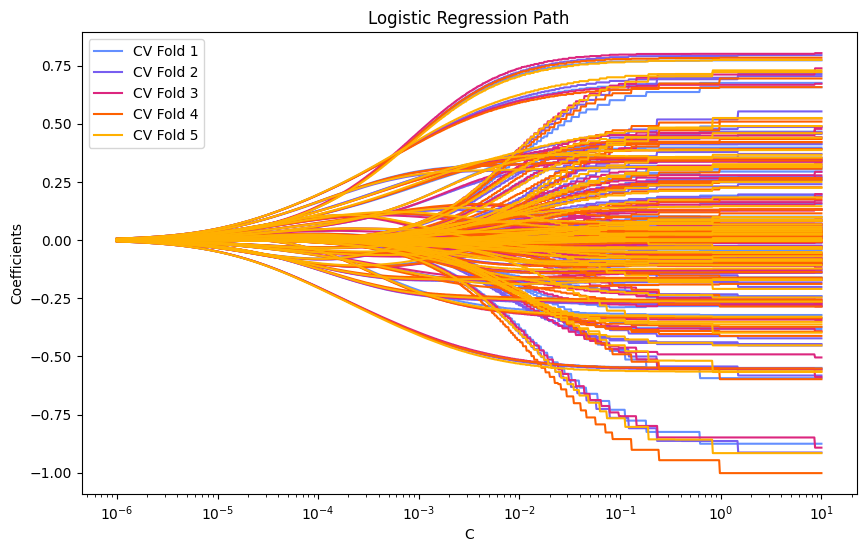

In [73]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Colorblind-friendly palette (IBM Color Blind Safe palette)
colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100", "#FFB000"]

plt.figure(figsize=(10, 6))
for j in range(coefs_.shape[0]):
    for i in range(coefs_.shape[2]-1):
        plt.plot(cs, coefs_[j, :, i], color=colors[j])

ymin, ymax = plt.ylim()
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Coefficients")
plt.title("Logistic Regression Path")
plt.legend(handles=[mlines.Line2D([], [], color=colors[i], label=f'CV Fold {i+1}') for i in range(len(colors))])
plt.axis("tight")
plt.show()

That's unintelligible (it's literally $5 \times 60 = 300$ plots). But from the few strands we can pick out, the folds seem to be generally aligned. At least enough so that we can just look at one of them and call it a day

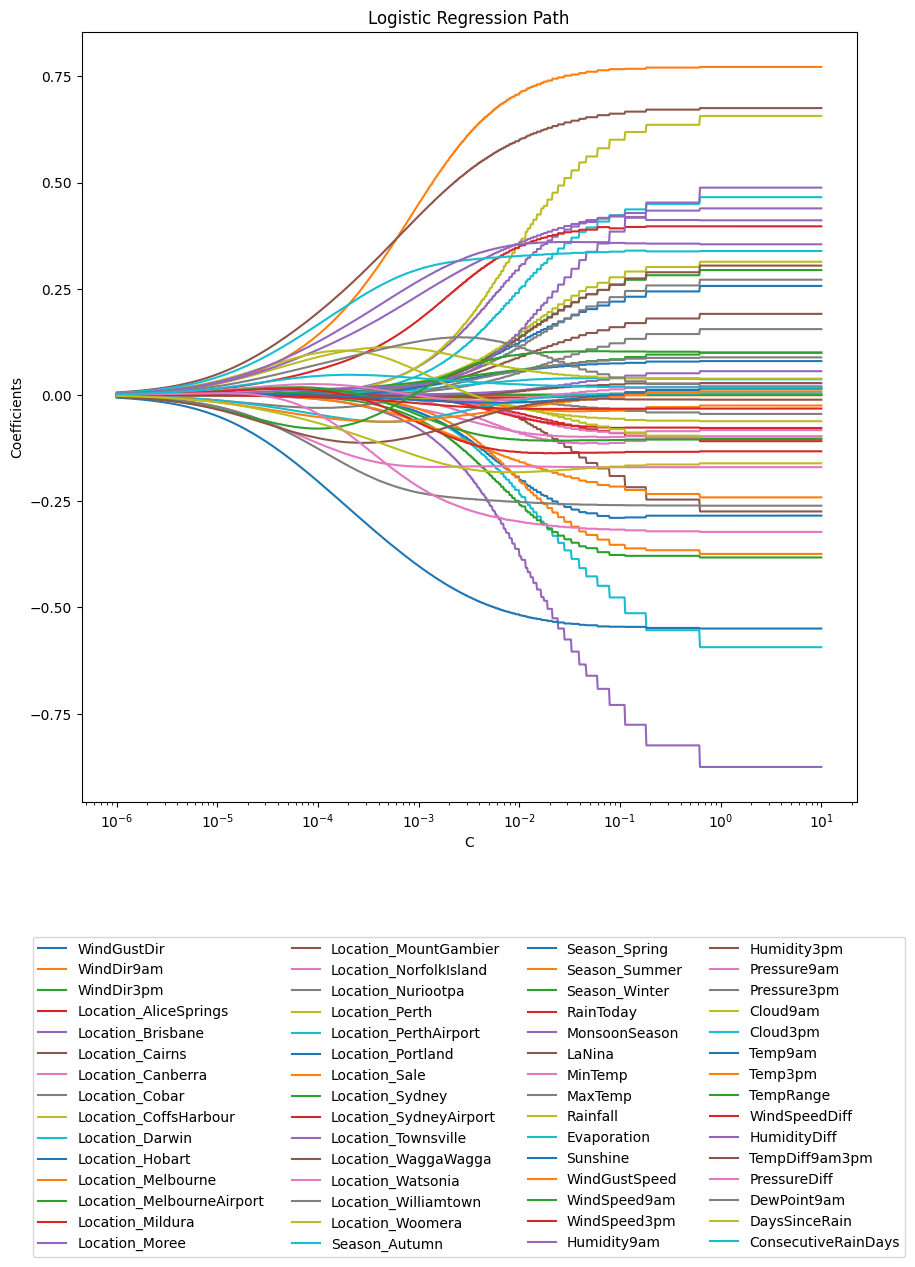

In [75]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Colorblind-friendly palette (IBM Color Blind Safe palette)

plt.figure(figsize=(10, 10))
for i in range(coefs_.shape[2]-1):
    plt.plot(cs, coefs_[0, :, i], label=fitted_features[i])

ymin, ymax = plt.ylim()
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Coefficients")
plt.title("Logistic Regression Path")
plt.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.6))
plt.axis("tight")
plt.show()

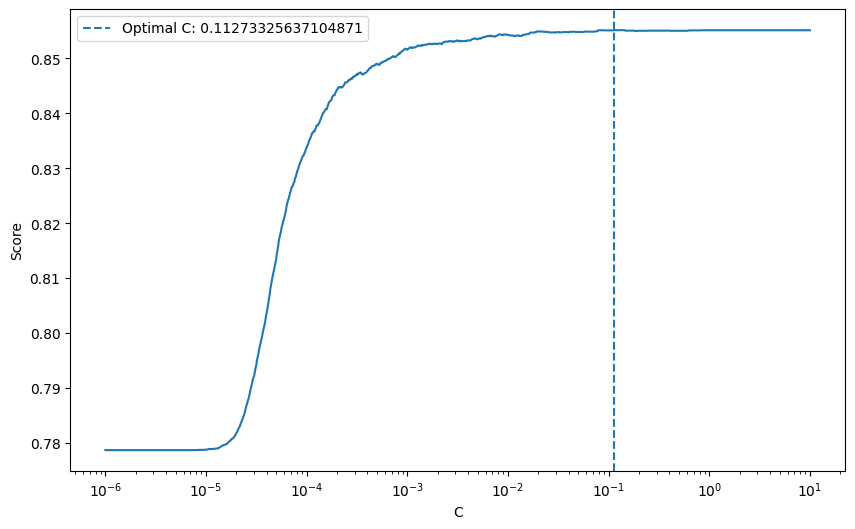

In [98]:
f, ax = plt.subplots(figsize=(10, 6))

mean_scores = lrcv_model.scores_[1].mean(axis=0)
ax.plot(cs, mean_scores)
ax.axvline(lrcv_model.C_[0], ls='--', label=f"Optimal C: {lrcv_model.C_[0]}")
ax.set_xscale('log')
ax.set_ylabel('Score')
ax.set_xlabel('C')
plt.legend()
plt.plot();

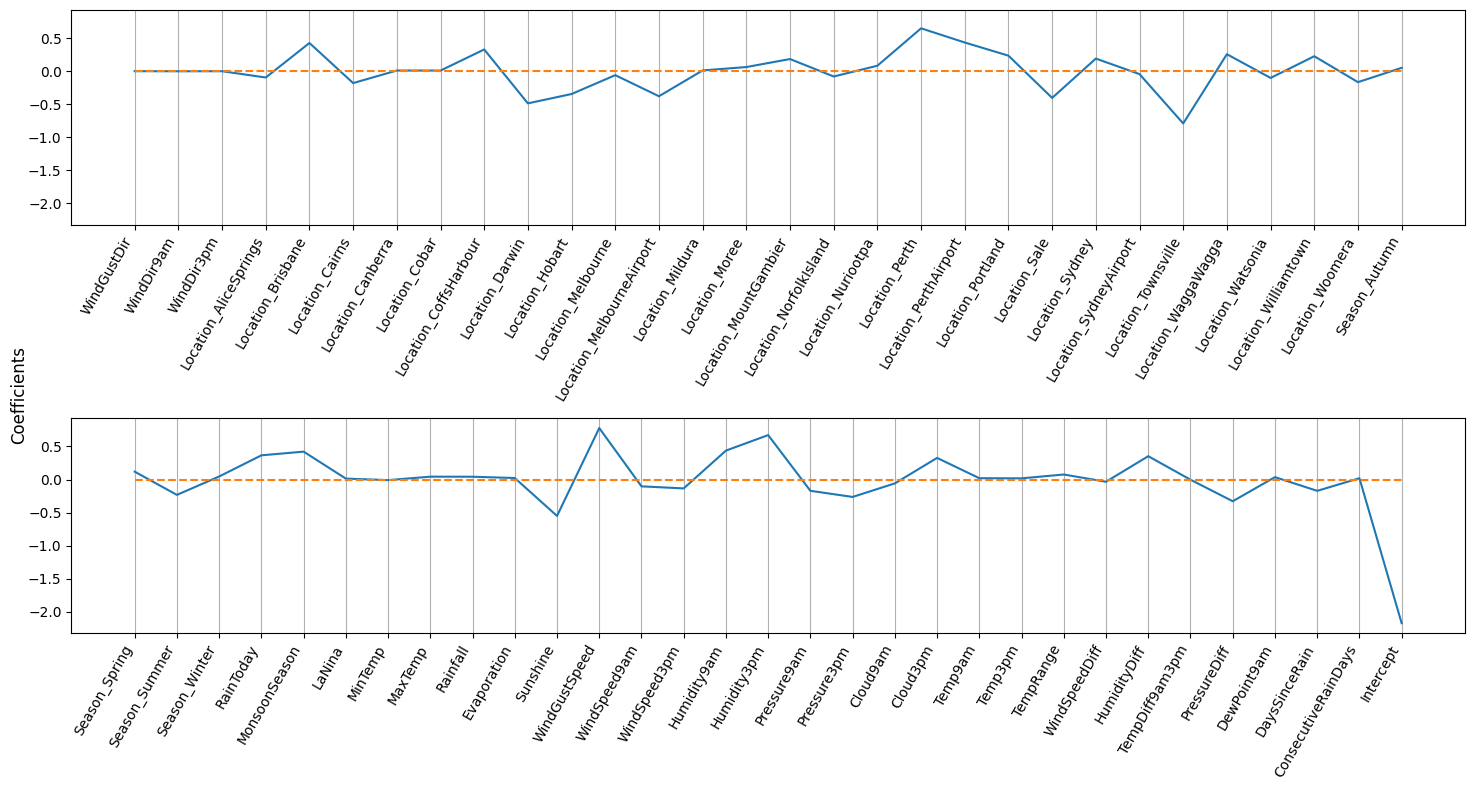

In [122]:
lrcv_coef = lrcv_model.coef_[0]
fitted_features = lr['columntransformer'].get_feature_names_out()
fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
lrcv_coef = np.append(lrcv_coef, lrcv_model.intercept_)
fitted_features.append('Intercept')

f, axs = plt.subplots(nrows=2, figsize=(15,8))

n_feat = len(fitted_features)
half = n_feat // 2

feature_coefs(axs[0], lrcv_coef[:half], fitted_features[:half])
feature_coefs(axs[1], lrcv_coef[half:], fitted_features[half:])
axs[0].sharey(axs[1])
f.supylabel('Coefficients')
f.tight_layout()
plt.show();

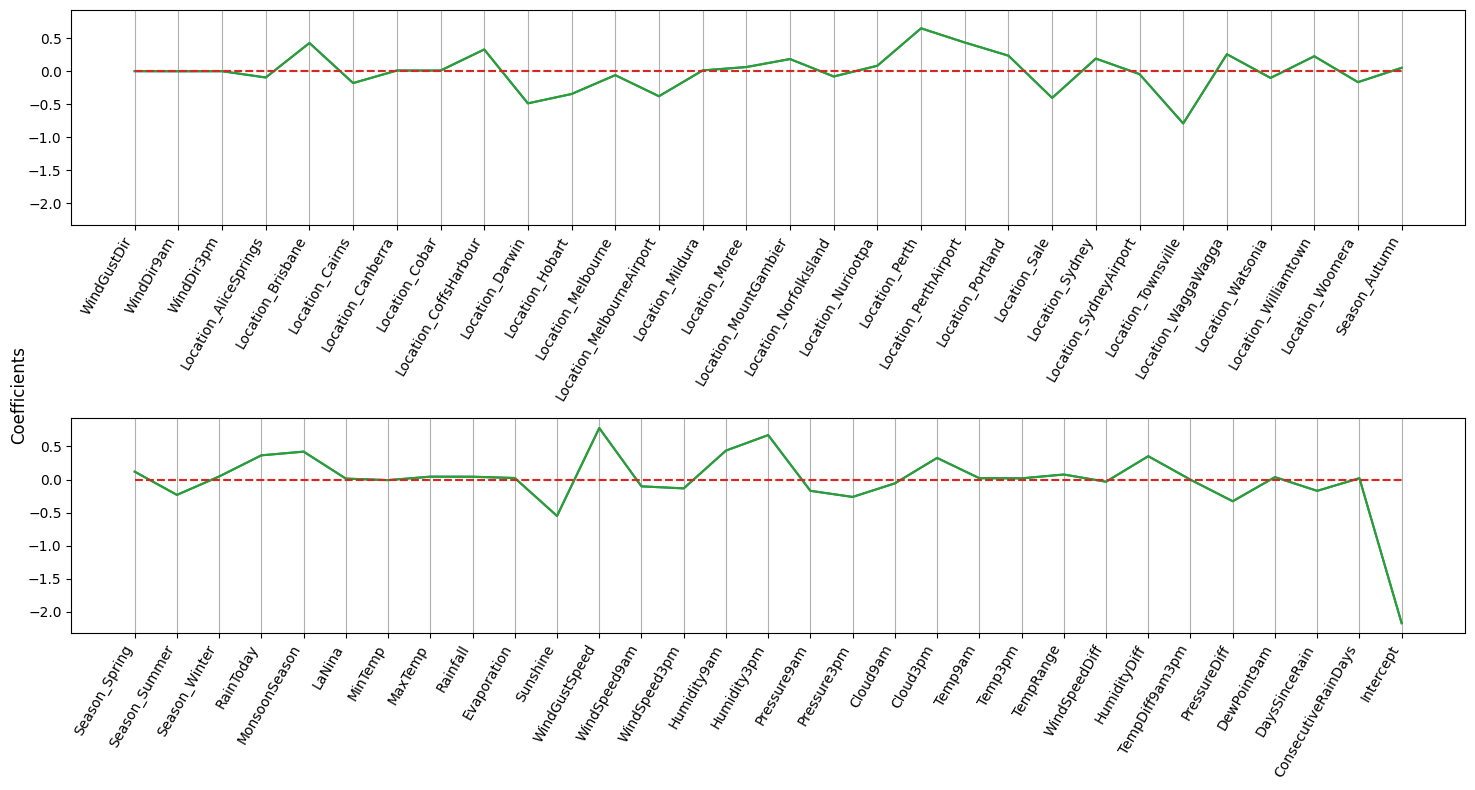

In [125]:
lrcv_coef = lrcv_model.coef_[0]
fitted_features = lr['columntransformer'].get_feature_names_out()
fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
lrcv_coef = np.append(lrcv_coef, lrcv_model.intercept_)
fitted_features.append('Intercept')

f, axs = plt.subplots(nrows=2, figsize=(15,8))

n_feat = len(fitted_features)
half = n_feat // 2

feature_coefs(axs[0], lrcv_coef[:half], fitted_features[:half])
feature_coefs(axs[1], lrcv_coef[half:], fitted_features[half:])
feature_coefs(axs[0], lr_coef[:half], fitted_features[:half])
feature_coefs(axs[1], lr_coef[half:], fitted_features[half:])
axs[0].sharey(axs[1])
axs[0].xaxis.grid()
axs[1].xaxis.grid()
f.supylabel('Coefficients')
f.tight_layout()
plt.show();

### Decision Tree

### Improved Model
Random forest, boosting, other ensemble

## Evaluation
With confucion matrix and suitable classification matrix

## Limitations

### False Positives and Negatives

## References